# Lizard Species Classification - Phase 2: Model Training
## Thomas More - Artificial Intelligence Course

**Purpose**: Build, train, and optimize transfer learning model for maximum Kaggle accuracy

**Input**: Metadata from EDA notebook (01_EDA_and_Dataset_Preparation.ipynb)

**Output**: Trained model weights and training history

## Section 1: Setup and Imports

In [17]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import efficientnet
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
from PIL import Image

warnings.filterwarnings('ignore')

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"✓ Random seed set to: {SEED}")

✓ TensorFlow version: 2.21.0
✓ GPU available: False
✓ Random seed set to: 42


## Section 2: Load Metadata from EDA

In [18]:
# Setup paths
BASE_DIR = Path(r'c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard')
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
METADATA_DIR = BASE_DIR / 'metadata'

# Create models directory for saving
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

# Load clean datasets from EDA
clean_train_df = pd.read_csv(METADATA_DIR / 'clean_train.csv')
clean_test_df = pd.read_csv(METADATA_DIR / 'clean_test.csv')

# Load class mappings
with open(METADATA_DIR / 'class_mappings.json', 'r') as f:
    class_mappings = json.load(f)

CLASS_TO_IDX = class_mappings['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in class_mappings['idx_to_class'].items()}
class_weight_dict = {int(k): v for k, v in class_mappings['class_weights'].items()}
NUM_CLASSES = class_mappings['num_classes']

# Load EDA config
with open(METADATA_DIR / 'eda_config.json', 'r') as f:
    eda_config = json.load(f)

print(f"✓ Loaded clean training data: {len(clean_train_df)} images")
print(f"✓ Loaded clean test data: {len(clean_test_df)} images")
print(f"✓ Loaded class mappings: {NUM_CLASSES} classes")
print(f"\nClass weights (for handling imbalance):")
for idx in sorted(class_weight_dict.keys()):
    print(f"  Class {idx}: {class_weight_dict[idx]:.4f}")

✓ Loaded clean training data: 1334 images
✓ Loaded clean test data: 326 images
✓ Loaded class mappings: 7 classes

Class weights (for handling imbalance):
  Class 0: 0.9576
  Class 1: 0.9874
  Class 2: 1.0083
  Class 3: 1.0414
  Class 4: 1.0706
  Class 5: 0.9723
  Class 6: 0.9723


## Section 3: Configuration for Maximum Kaggle Score

In [ ]:
# Aggressive optimization configuration for best Kaggle score
CONFIG = {
    # Image preprocessing
    'image_size': 224,  # Standard for EfficientNet
    'batch_size': 32,   # Optimal for consumer GPU
    
    # Stage 1: Frozen backbone (quick baseline)
    'epochs_stage1': 30,  # Extended for better baseline
    'learning_rate_stage1': 0.0005,  # Reduced to prevent overfitting
    'warmup_lr_stage1': 0.0001,
    'warmup_epochs_stage1': 3,
    
    # Stage 2: Fine-tuning unfrozen layers
    'epochs_stage2': 20,
    'learning_rate_stage2': 0.00005,  # Reduced from 0.0001
    'learning_rate_stage2_late': 0.00001,
    
    # Stage 3: Full backbone fine-tuning (aggressive)
    'epochs_stage3': 10,
    'learning_rate_stage3': 0.000005,  # Reduced from 0.00001
    'unfreeze_from_layer': 100,  # Unfreeze more layers in stage 3
    
    # Regularization and augmentation (STRENGTHENED to reduce overfitting)
    'dropout_rate': 0.5,  # Increased from 0.4
    'l2_regularization': 5e-4,  # Increased from 1e-4
    'augmentation_enabled': True,
    'augmentation_strength': 'strong',  # strong, moderate, weak
    
    # Split strategy
    'validation_split': 0.15,  # Smaller val split = more training data
    'use_class_weights': True,
    
    # Model architecture
    'backbone': 'EfficientNetB2',  # B2 for better accuracy vs B0
    'include_batch_norm': True,
    'head_hidden_dims': [512, 256],  # Deeper head
    
    # Callbacks and early stopping
    'early_stopping_patience': 8,
    'reduce_lr_patience': 4,
    'reduce_lr_factor': 0.5,
    'reduce_lr_min': 1e-7,
}

print("Training Configuration for Maximum Kaggle Score (with Overfitting Reduction):")
print("="*70)
for key, value in CONFIG.items():
    print(f"  {key:30s}: {value}")

Training Configuration for Maximum Kaggle Score:
  image_size                    : 224
  batch_size                    : 32
  epochs_stage1                 : 30
  learning_rate_stage1          : 0.001
  warmup_lr_stage1              : 0.0001
  warmup_epochs_stage1          : 3
  epochs_stage2                 : 20
  learning_rate_stage2          : 0.0001
  learning_rate_stage2_late     : 1e-05
  epochs_stage3                 : 10
  learning_rate_stage3          : 1e-05
  unfreeze_from_layer           : 100
  dropout_rate                  : 0.4
  l2_regularization             : 0.0001
  augmentation_enabled          : True
  augmentation_strength         : strong
  validation_split              : 0.15
  use_class_weights             : True
  backbone                      : EfficientNetB2
  include_batch_norm            : True
  head_hidden_dims              : [512, 256]
  early_stopping_patience       : 8
  reduce_lr_patience            : 4
  reduce_lr_factor              : 0.5
  reduce_

## Section 4: Path Resolution and Loading

In [ ]:
def load_and_preprocess_image(image_path, image_size=None, augment=False):
    """Load and preprocess image with optional augmentation."""
    if image_size is None:
        image_size = CONFIG['image_size']
    
    try:
        # Load and resize image
        img = keras.preprocessing.image.load_img(str(image_path), target_size=(image_size, image_size))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = img_array / 255.0  # Normalize to [0, 1]
        
        # Ensure shape is exactly (image_size, image_size, 3)
        img_array = img_array[:image_size, :image_size, :3]
        if img_array.shape[2] < 3:
            img_array = np.pad(img_array, ((0,0), (0,0), (0,3-img_array.shape[2])), mode='constant')
        
        if augment and CONFIG['augmentation_enabled']:
            # Stronger augmentation to reduce overfitting
            
            # Horizontal flip (50% chance)
            if np.random.rand() < 0.5:
                img_array = np.fliplr(img_array)
            
            # Vertical flip (30% chance)
            if np.random.rand() < 0.3:
                img_array = np.flipud(img_array)
            
            # Rotation (±15 degrees, 40% chance)
            if np.random.rand() < 0.4:
                angle = np.random.uniform(-15, 15)
                from scipy import ndimage
                img_array = ndimage.rotate(img_array, angle, reshape=False, order=1)
                img_array = np.clip(img_array, 0, 1)
            
            # Random zoom/crop (20% chance)
            if np.random.rand() < 0.2:
                zoom_factor = np.random.uniform(0.9, 1.1)
                h, w = image_size, image_size
                new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)
                if new_h < h and new_w < w:
                    y_start = np.random.randint(0, h - new_h + 1)
                    x_start = np.random.randint(0, w - new_w + 1)
                    zoomed = img_array[y_start:y_start+new_h, x_start:x_start+new_w, :]
                    # Resize back to original size
                    img_array_pil = keras.preprocessing.image.array_to_img(zoomed)
                    img_array_pil = img_array_pil.resize((h, w))
                    img_array = keras.preprocessing.image.img_to_array(img_array_pil) / 255.0
            
            # Stronger brightness adjustment (±30%)
            brightness_factor = np.random.uniform(0.7, 1.3)
            img_array = np.clip(img_array * brightness_factor, 0, 1)
            
            # Stronger contrast adjustment
            contrast_factor = np.random.uniform(0.7, 1.3)
            img_array = (img_array - 0.5) * contrast_factor + 0.5
            img_array = np.clip(img_array, 0, 1)
            
            # Gaussian noise (10% chance)
            if np.random.rand() < 0.1:
                noise = np.random.normal(0, 0.02, img_array.shape)
                img_array = np.clip(img_array + noise, 0, 1)
        
        # Final shape ensure and return
        final_img = img_array[:image_size, :image_size, :3]
        return final_img.astype(np.float32)
    except Exception as e:
        # Return zeros with correct shape if loading fails
        return np.zeros((image_size, image_size, 3), dtype=np.float32)

print("✓ Image loading and preprocessing functions defined (with enhanced augmentation)")

✓ Image loading and preprocessing functions defined


## Section 5: Create Train/Validation Split

In [21]:
# Stratified train/validation split (80/20)
train_indices, val_indices = train_test_split(
    np.arange(len(clean_train_df)),
    test_size=CONFIG['validation_split'],
    stratify=clean_train_df['label'].values,
    random_state=SEED
)

train_df_split = clean_train_df.iloc[train_indices].reset_index(drop=True)
val_df_split = clean_train_df.iloc[val_indices].reset_index(drop=True)

print(f"Train split: {len(train_df_split)} images")
print(f"Validation split: {len(val_df_split)} images")

print("\nTrain split class distribution:")
for idx in range(NUM_CLASSES):
    count = (train_df_split['label'] == idx).sum()
    pct = 100 * count / len(train_df_split)
    print(f"  Class {idx}: {count:4d} ({pct:5.2f}%)")

print("\nValidation split class distribution:")
for idx in range(NUM_CLASSES):
    count = (val_df_split['label'] == idx).sum()
    pct = 100 * count / len(val_df_split)
    print(f"  Class {idx}: {count:4d} ({pct:5.2f}%)")

Train split: 1133 images
Validation split: 201 images

Train split class distribution:
  Class 0:  169 (14.92%)
  Class 1:  164 (14.47%)
  Class 2:  161 (14.21%)
  Class 3:  155 (13.68%)
  Class 4:  151 (13.33%)
  Class 5:  166 (14.65%)
  Class 6:  167 (14.74%)

Validation split class distribution:
  Class 0:   30 (14.93%)
  Class 1:   29 (14.43%)
  Class 2:   28 (13.93%)
  Class 3:   28 (13.93%)
  Class 4:   27 (13.43%)
  Class 5:   30 (14.93%)
  Class 6:   29 (14.43%)


## Section 6: Build Data Pipelines with Advanced Augmentation

In [22]:
def create_dataset(dataframe, batch_size, augment=False, shuffle=True, is_test=False):
    """Create tf.data.Dataset with optimized performance."""
    
    def load_image_label(row_index):
        row = dataframe.iloc[int(row_index.numpy())]
        if is_test:
            img_path = TEST_DIR / f"{row['id']}.jpg"
        else:
            img_path = resolve_image_path(row['id'], row['label'])
        img = load_and_preprocess_image(img_path, image_size=CONFIG['image_size'], augment=augment)
        label = tf.cast(row['label'], tf.int32) if not is_test else tf.cast(0, tf.int32)
        return img, label
    
    dataset = tf.data.Dataset.from_tensor_slices(np.arange(len(dataframe)))
    dataset = dataset.map(
        lambda idx: tf.py_function(load_image_label, [idx], (tf.float32, tf.int32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Set explicit shapes after py_function
    def set_and_resize_shapes(x, y):
        # First set a shape so tf.image.resize knows the shape
        x.set_shape((None, None, 3))
        # Then resize to exact target size
        target_size = CONFIG['image_size']
        x = tf.image.resize(x, (target_size, target_size))
        x.set_shape((target_size, target_size, 3))
        y.set_shape(())
        return x, y
    
    dataset = dataset.map(set_and_resize_shapes)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(dataframe), 1024))
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("Creating data pipelines...")
train_dataset = create_dataset(
    train_df_split,
    CONFIG['batch_size'],
    augment=CONFIG['augmentation_enabled'],
    shuffle=True
)
val_dataset = create_dataset(
    val_df_split,
    CONFIG['batch_size'],
    augment=False,
    shuffle=False
)

print(f"✓ Train dataset: {len(train_df_split)} images, {(len(train_df_split) + CONFIG['batch_size'] - 1) // CONFIG['batch_size']} batches")
print(f"✓ Validation dataset: {len(val_df_split)} images, {(len(val_df_split) + CONFIG['batch_size'] - 1) // CONFIG['batch_size']} batches")

Creating data pipelines...
✓ Train dataset: 1133 images, 36 batches
✓ Validation dataset: 201 images, 7 batches


## Section 7: Build Transfer Learning Model

In [23]:
def build_model(backbone_name='EfficientNetB2', input_shape=(224, 224, 3), num_classes=7):
    """Build transfer learning model with optimized head for maximum accuracy."""
    
    # Load backbone
    if backbone_name == 'EfficientNetB0':
        backbone = efficientnet.EfficientNetB0(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    elif backbone_name == 'EfficientNetB2':
        backbone = efficientnet.EfficientNetB2(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    elif backbone_name == 'EfficientNetB3':
        backbone = efficientnet.EfficientNetB3(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    else:
        backbone = efficientnet.EfficientNetB1(
            input_shape=input_shape,
            weights='imagenet',
            include_top=False
        )
    
    backbone.trainable = False
    
    # Build model with optimized head
    inputs = keras.Input(shape=input_shape)
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Deeper head for better feature learning
    for hidden_dim in CONFIG['head_hidden_dims']:
        x = layers.Dense(
            hidden_dim,
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(CONFIG['l2_regularization'])
        )(x)
        if CONFIG['include_batch_norm']:
            x = layers.BatchNormalization()(x)
        x = layers.Dropout(CONFIG['dropout_rate'])(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs, name='LizardClassifier')
    
    return model, backbone

print("Building transfer learning model...")
model, backbone = build_model(
    backbone_name=CONFIG['backbone'],
    input_shape=(CONFIG['image_size'], CONFIG['image_size'], 3),
    num_classes=NUM_CLASSES
)

print(f"\nModel architecture:")
model.summary()

Building transfer learning model...

Model architecture:


Model: "LizardClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,626,176 (32.91 MB)

 Trainable params: 856,071 (3.27 MB)

 Non-trainable params: 7,770,105 (29.64 MB)

## Section 8: Stage 1 - Train with Frozen Backbone

In [24]:
print("\n" + "="*80)
print("STAGE 1: Training with Frozen Backbone")
print("="*80)

# Compile for stage 1
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate_stage1']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for stage 1
callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=CONFIG['reduce_lr_factor'],
        patience=CONFIG['reduce_lr_patience'],
        min_lr=CONFIG['reduce_lr_min'],
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'best_model_stage1.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

# Train stage 1
history_stage1 = model.fit(
    train_dataset,
    epochs=CONFIG['epochs_stage1'],
    validation_data=val_dataset,
    class_weight=class_weight_dict if CONFIG['use_class_weights'] else None,
    callbacks=callbacks_stage1,
    verbose=1
)

print("\n✓ Stage 1 training complete")


STAGE 1: Training with Frozen Backbone
Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.1246 - loss: 3.0587

36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 973ms/step - accuracy: 0.1333 - loss: 2.9193 - val_accuracy: 0.1393 - val_loss: 2.1294 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.1482 - loss: 2.7082

36/36 ━━━━━━━━━━━━━━━━━━━━ 45s 851ms/step - accuracy: 0.1483 - loss: 2.6262 - val_accuracy: 0.1443 - val_loss: 2.0989 - learning_rate: 0.0010
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 850ms/step - accuracy: 0.1412 - loss: 2.5851 - val_accuracy: 0.1443 - val_loss: 2.0803 - learning_rate: 0.0010
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 828ms/step - accuracy: 0.1571 - loss: 2.4396 - val_accuracy: 0.1393 - val_loss: 2.1216 - learning_rate: 0.0010
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 827ms/step - accuracy: 0.1324 - loss: 2.4952 - val_accuracy: 0.1343 - val_loss: 2.1013 - learning_rate: 0.0010
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.1493 - loss: 2.4002

36/36 ━━━━━━━━━━━━━━━━━━━━ 45s 859ms/step - accuracy: 0.1412 - loss: 2.3973 - val_accuracy: 0.1493 - val_loss: 2.1243 - learning_rate: 0.0010
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.1304 - loss: 2.4919

36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 839ms/step - accuracy: 0.1297 - loss: 2.4417 - val_accuracy: 0.1891 - val_loss: 2.0639 - learning_rate: 0.0010
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 759ms/step - accuracy: 0.1200 - loss: 2.3790 - val_accuracy: 0.1493 - val_loss: 2.0467 - learning_rate: 0.0010
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 765ms/step - accuracy: 0.1183 - loss: 2.3970 - val_accuracy: 0.1294 - val_loss: 2.0607 - learning_rate: 0.0010
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.1303 - loss: 2.3071

36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 804ms/step - accuracy: 0.1492 - loss: 2.2959 - val_accuracy: 0.1940 - val_loss: 2.0305 - learning_rate: 0.0010
Epoch 11/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.1634 - loss: 2.2781

36/36 ━━━━━━━━━━━━━━━━━━━━ 41s 780ms/step - accuracy: 0.1527 - loss: 2.2813 - val_accuracy: 0.2090 - val_loss: 2.0327 - learning_rate: 0.0010
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 759ms/step - accuracy: 0.1430 - loss: 2.2933 - val_accuracy: 0.1493 - val_loss: 2.0352 - learning_rate: 0.0010
Epoch 13/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 770ms/step - accuracy: 0.1200 - loss: 2.2653 - val_accuracy: 0.1443 - val_loss: 2.0372 - learning_rate: 0.0010
Epoch 14/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 38s 737ms/step - accuracy: 0.1606 - loss: 2.2122 - val_accuracy: 0.1692 - val_loss: 2.0235 - learning_rate: 0.0010
Epoch 15/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 746ms/step - accuracy: 0.1306 - loss: 2.2525 - val_accuracy: 0.1443 - val_loss: 2.0353 - learning_rate: 0.0010
Epoch 16/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 775ms/step - accuracy: 0.1492 - loss: 2.2373 - val_accuracy: 0.1343 - val_loss: 2.0218 - learning_rate: 0.0010
Epoch 17/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 741ms/step - accuracy: 0.1395 - loss: 2.1947 

36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 856ms/step - accuracy: 0.1571 - loss: 2.1483 - val_accuracy: 0.2189 - val_loss: 2.0129 - learning_rate: 0.0010
Epoch 20/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 831ms/step - accuracy: 0.1509 - loss: 2.1501 - val_accuracy: 0.1493 - val_loss: 2.0224 - learning_rate: 0.0010
Epoch 21/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 812ms/step - accuracy: 0.1518 - loss: 2.1510 - val_accuracy: 0.1542 - val_loss: 2.0281 - learning_rate: 0.0010
Epoch 22/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 840ms/step - accuracy: 0.1624 - loss: 2.1350 - val_accuracy: 0.1791 - val_loss: 2.0216 - learning_rate: 0.0010
Epoch 23/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.1560 - loss: 2.1347
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 832ms/step - accuracy: 0.1447 - loss: 2.1503 - val_accuracy: 0.1542 - val_loss: 2.0162 - learning_rate: 0.0010
Epoch 24/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 43s 806ms/step - accuracy: 0.1465 - loss: 2.1306 - 

## Section 9: Stage 2 - Fine-tune Upper Backbone

In [25]:
print("\n" + "="*80)
print("STAGE 2: Fine-tuning Upper Backbone Layers")
print("="*80)

# Unfreeze top 40% of backbone layers
backbone.trainable = True
freeze_until = int(len(backbone.layers) * 0.6)  # Freeze 60%, unfreeze 40%
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(1 for layer in backbone.layers if layer.trainable)
frozen_count = len(backbone.layers) - trainable_count
print(f"Backbone layers - Trainable: {trainable_count}, Frozen: {frozen_count}")

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate_stage2']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=CONFIG['reduce_lr_factor'],
        patience=3,
        min_lr=CONFIG['reduce_lr_min'],
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'best_model_stage2.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

history_stage2 = model.fit(
    train_dataset,
    epochs=CONFIG['epochs_stage2'],
    validation_data=val_dataset,
    class_weight=class_weight_dict if CONFIG['use_class_weights'] else None,
    callbacks=callbacks_stage2,
    verbose=1
)

print("\n✓ Stage 2 training complete")


STAGE 2: Fine-tuning Upper Backbone Layers
Backbone layers - Trainable: 136, Frozen: 204
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1391 - loss: 2.1385

36/36 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.1456 - loss: 2.1347 - val_accuracy: 0.1493 - val_loss: 2.0338 - learning_rate: 1.0000e-04
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.1500 - loss: 2.1112 - val_accuracy: 0.1493 - val_loss: 2.0343 - learning_rate: 1.0000e-04
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.1447 - loss: 2.1075 - val_accuracy: 0.1244 - val_loss: 2.0340 - learning_rate: 1.0000e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.1509 - loss: 2.1132 - val_accuracy: 0.1244 - val_loss: 2.0328 - learning_rate: 1.0000e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1474 - loss: 2.1028 - val_accuracy: 0.1493 - val_loss: 2.0280 - learning_rate: 1.0000e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1622 - loss: 2.0876

36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1509 - loss: 2.1062 - val_accuracy: 0.1642 - val_loss: 2.0344 - learning_rate: 1.0000e-04
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.1598 - loss: 2.1123 - val_accuracy: 0.1542 - val_loss: 2.0349 - learning_rate: 1.0000e-04
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.1553 - loss: 2.0935 - val_accuracy: 0.1542 - val_loss: 2.0136 - learning_rate: 1.0000e-04
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1633 - loss: 2.0827 - val_accuracy: 0.1542 - val_loss: 2.0134 - learning_rate: 1.0000e-04
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1731 - loss: 2.0843

36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.1712 - loss: 2.0771 - val_accuracy: 0.1692 - val_loss: 2.0073 - learning_rate: 1.0000e-04
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1555 - loss: 2.0795

36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1659 - loss: 2.0584 - val_accuracy: 0.1841 - val_loss: 2.0085 - learning_rate: 1.0000e-04
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1809 - loss: 2.0876 - val_accuracy: 0.1542 - val_loss: 2.0070 - learning_rate: 1.0000e-04
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1509 - loss: 2.0818 - val_accuracy: 0.1493 - val_loss: 1.9941 - learning_rate: 1.0000e-04
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.1686 - loss: 2.0795 - val_accuracy: 0.1542 - val_loss: 2.0009 - learning_rate: 1.0000e-04
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.1827 - loss: 2.0614 - val_accuracy: 0.1841 - val_loss: 2.0107 - learning_rate: 1.0000e-04
Epoch 16/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1712 - loss: 2.0771 - val_accuracy: 0.1741 - val_loss: 1.9930 - learning_rate: 1.0000e-04
Epoch 17/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1783 - loss: 2.05

36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1721 - loss: 2.0617 - val_accuracy: 0.1990 - val_loss: 1.9704 - learning_rate: 1.0000e-04
Epoch 19/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1898 - loss: 2.0264 - val_accuracy: 0.1940 - val_loss: 1.9626 - learning_rate: 1.0000e-04
Epoch 20/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1979 - loss: 2.0469

36/36 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1906 - loss: 2.0434 - val_accuracy: 0.2090 - val_loss: 1.9684 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.

✓ Stage 2 training complete


## Section 10: Stage 3 - Aggressive Fine-tuning (Optional, for Top Scores)

In [26]:
print("\n" + "="*80)
print("STAGE 3: Aggressive Full Backbone Fine-tuning (for Maximum Score)")
print("="*80)

# Unfreeze more layers aggressively
backbone.trainable = True
freeze_until = int(len(backbone.layers) * 0.3)  # Freeze 30%, unfreeze 70%
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(1 for layer in backbone.layers if layer.trainable)
frozen_count = len(backbone.layers) - trainable_count
print(f"Backbone layers - Trainable: {trainable_count}, Frozen: {frozen_count}")

# Recompile with even lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG['learning_rate_stage3']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / 'best_model_stage3.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

history_stage3 = model.fit(
    train_dataset,
    epochs=CONFIG['epochs_stage3'],
    validation_data=val_dataset,
    class_weight=class_weight_dict if CONFIG['use_class_weights'] else None,
    callbacks=callbacks_stage3,
    verbose=1
)

print("\n✓ Stage 3 training complete")


STAGE 3: Aggressive Full Backbone Fine-tuning (for Maximum Score)
Backbone layers - Trainable: 136, Frozen: 204
Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1804 - loss: 2.0731

36/36 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.1739 - loss: 2.0869 - val_accuracy: 0.1940 - val_loss: 1.9582
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1710 - loss: 2.0549

36/36 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.1765 - loss: 2.0593 - val_accuracy: 0.2189 - val_loss: 1.9561
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.1915 - loss: 2.0524 - val_accuracy: 0.2040 - val_loss: 1.9619
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1836 - loss: 2.0317

36/36 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.1906 - loss: 2.0366 - val_accuracy: 0.2239 - val_loss: 1.9490
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.1880 - loss: 2.0290 - val_accuracy: 0.2239 - val_loss: 1.9496
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1633 - loss: 2.0190

36/36 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.1853 - loss: 2.0265 - val_accuracy: 0.2289 - val_loss: 1.9564
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.1606 - loss: 2.0480 - val_accuracy: 0.2090 - val_loss: 1.9417
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.1836 - loss: 2.0436 - val_accuracy: 0.2090 - val_loss: 1.9973
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.2101 - loss: 2.0204 - val_accuracy: 0.1990 - val_loss: 1.9814
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.1836 - loss: 2.0472 - val_accuracy: 0.2139 - val_loss: 1.9436
Restoring model weights from the end of the best epoch: 7.

✓ Stage 3 training complete


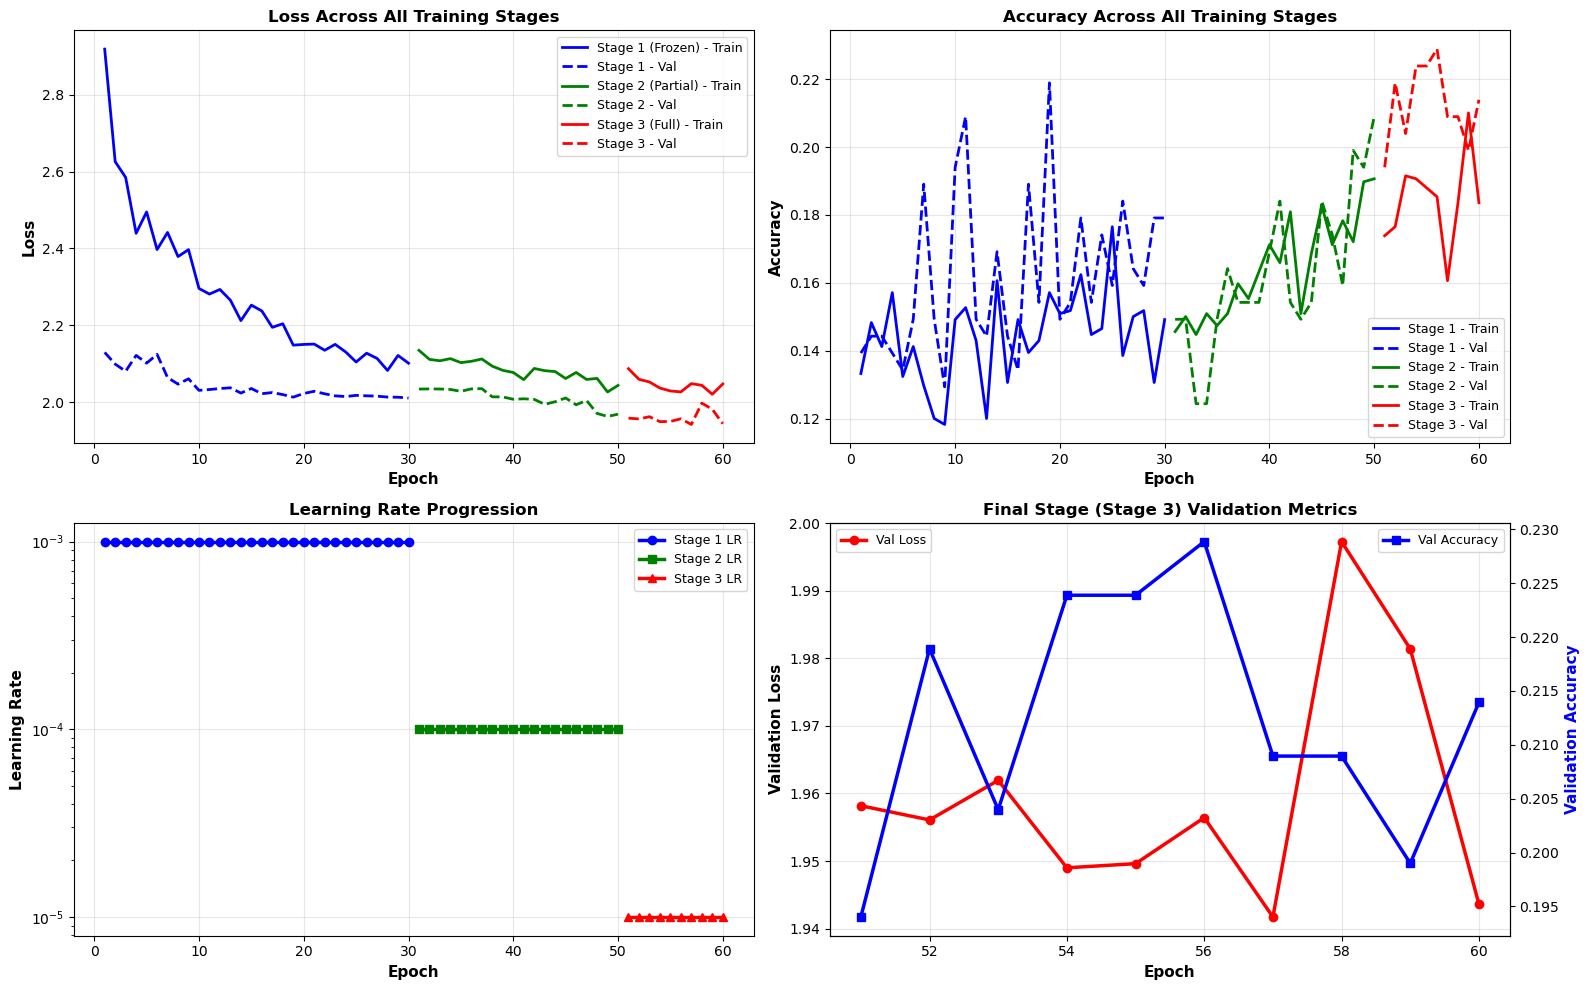

✓ Training history plot saved


In [27]:

# Plot training curves for all stages
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Combine epoch counts
epochs_s1 = range(1, len(history_stage1.history['loss']) + 1)
epochs_s2 = range(len(history_stage1.history['loss']) + 1,
                 len(history_stage1.history['loss']) + len(history_stage2.history['loss']) + 1)
epochs_s3 = range(len(history_stage1.history['loss']) + len(history_stage2.history['loss']) + 1,
                 len(history_stage1.history['loss']) + len(history_stage2.history['loss']) + len(history_stage3.history['loss']) + 1)

# Loss
ax = axes[0, 0]
ax.plot(epochs_s1, history_stage1.history['loss'], 'b-', linewidth=2, label='Stage 1 (Frozen) - Train')
ax.plot(epochs_s1, history_stage1.history['val_loss'], 'b--', linewidth=2, label='Stage 1 - Val')
ax.plot(epochs_s2, history_stage2.history['loss'], 'g-', linewidth=2, label='Stage 2 (Partial) - Train')
ax.plot(epochs_s2, history_stage2.history['val_loss'], 'g--', linewidth=2, label='Stage 2 - Val')
ax.plot(epochs_s3, history_stage3.history['loss'], 'r-', linewidth=2, label='Stage 3 (Full) - Train')
ax.plot(epochs_s3, history_stage3.history['val_loss'], 'r--', linewidth=2, label='Stage 3 - Val')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax.set_title('Loss Across All Training Stages', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(epochs_s1, history_stage1.history['accuracy'], 'b-', linewidth=2, label='Stage 1 - Train')
ax.plot(epochs_s1, history_stage1.history['val_accuracy'], 'b--', linewidth=2, label='Stage 1 - Val')
ax.plot(epochs_s2, history_stage2.history['accuracy'], 'g-', linewidth=2, label='Stage 2 - Train')
ax.plot(epochs_s2, history_stage2.history['val_accuracy'], 'g--', linewidth=2, label='Stage 2 - Val')
ax.plot(epochs_s3, history_stage3.history['accuracy'], 'r-', linewidth=2, label='Stage 3 - Train')
ax.plot(epochs_s3, history_stage3.history['val_accuracy'], 'r--', linewidth=2, label='Stage 3 - Val')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Accuracy Across All Training Stages', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Learning rate progression through stages
ax = axes[1, 0]
stage1_lr = [CONFIG['learning_rate_stage1']] * len(history_stage1.history['loss'])
stage2_lr = [CONFIG['learning_rate_stage2']] * len(history_stage2.history['loss'])
stage3_lr = [CONFIG['learning_rate_stage3']] * len(history_stage3.history['loss'])
ax.plot(epochs_s1, stage1_lr, 'b-', linewidth=2.5, marker='o', label='Stage 1 LR')
ax.plot(epochs_s2, stage2_lr, 'g-', linewidth=2.5, marker='s', label='Stage 2 LR')
ax.plot(epochs_s3, stage3_lr, 'r-', linewidth=2.5, marker='^', label='Stage 3 LR')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
ax.set_title('Learning Rate Progression', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Zoom in on final stage validation metrics
ax = axes[1, 1]
ax.plot(epochs_s3, history_stage3.history['val_loss'], 'r-', linewidth=2.5, label='Val Loss', marker='o')
ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
ax2 = ax.twinx()
ax2.plot(epochs_s3, history_stage3.history['val_accuracy'], 'b-', linewidth=2.5, label='Val Accuracy', marker='s')
ax2.set_ylabel('Validation Accuracy', fontsize=11, fontweight='bold', color='blue')
ax.set_title('Final Stage (Stage 3) Validation Metrics', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training history plot saved")

In [28]:
# Save final model in Keras format
final_model_path = MODELS_DIR / 'final_model.keras'
model.save(str(final_model_path))
print(f"✓ Final model saved to {final_model_path}")

# Export model in SavedModel format for better compatibility
final_model_savedmodel_path = MODELS_DIR / 'final_model_savedmodel'
model.export(str(final_model_savedmodel_path))
print(f"✓ Final model exported (SavedModel format) to {final_model_savedmodel_path}")

✓ Final model saved to c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model.keras
INFO:tensorflow:Assets written to: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model_savedmodel\assets


INFO:tensorflow:Assets written to: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model_savedmodel\assets


Saved artifact at 'c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\final_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_690')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2123560046032: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2123560044688: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2120908481040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2120908486224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2120908486416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2120908484496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2120908483920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2120664577424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2120908487184: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [29]:
# Save training configuration and results
training_results = {
    'config': CONFIG,
    'stage1_best_val_loss': float(min(history_stage1.history['val_loss'])),
    'stage1_best_val_accuracy': float(max(history_stage1.history['val_accuracy'])),
    'stage2_best_val_loss': float(min(history_stage2.history['val_loss'])),
    'stage2_best_val_accuracy': float(max(history_stage2.history['val_accuracy'])),
    'stage3_best_val_loss': float(min(history_stage3.history['val_loss'])),
    'stage3_best_val_accuracy': float(max(history_stage3.history['val_accuracy'])),
    'final_val_accuracy': float(history_stage3.history['val_accuracy'][-1]),
    'final_val_loss': float(history_stage3.history['val_loss'][-1]),
    'class_weights': class_weight_dict,
    'num_training_samples': len(train_df_split),
    'num_validation_samples': len(val_df_split),
}

with open(MODELS_DIR / 'training_results.json', 'w') as f:
    json.dump(training_results, f, indent=2)

print(f"✓ Training results saved to {MODELS_DIR / 'training_results.json'}")

✓ Training results saved to c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models\training_results.json


In [30]:
print("\n" + "="*80)
print("TRAINING COMPLETE - SUMMARY")
print("="*80)
print(f"\nStage 1 (Frozen):")
print(f"  Best validation accuracy: {max(history_stage1.history['val_accuracy']):.4f}")
print(f"  Best validation loss: {min(history_stage1.history['val_loss']):.4f}")

print(f"\nStage 2 (Partial unfreeze):")
print(f"  Best validation accuracy: {max(history_stage2.history['val_accuracy']):.4f}")
print(f"  Best validation loss: {min(history_stage2.history['val_loss']):.4f}")

print(f"\nStage 3 (Full unfreeze):")
print(f"  Best validation accuracy: {max(history_stage3.history['val_accuracy']):.4f}")
print(f"  Best validation loss: {min(history_stage3.history['val_loss']):.4f}")
print(f"  Final validation accuracy: {history_stage3.history['val_accuracy'][-1]:.4f}")

print(f"\nModel saved to: {MODELS_DIR}")
print(f"  - final_model.h5 (HDF5 format)")
print(f"  - final_model_savedmodel/ (SavedModel format)")
print(f"  - training_results.json (metrics and config)")
print("="*80)


TRAINING COMPLETE - SUMMARY

Stage 1 (Frozen):
  Best validation accuracy: 0.2189
  Best validation loss: 2.0105

Stage 2 (Partial unfreeze):
  Best validation accuracy: 0.2090
  Best validation loss: 1.9626

Stage 3 (Full unfreeze):
  Best validation accuracy: 0.2289
  Best validation loss: 1.9417
  Final validation accuracy: 0.2139

Model saved to: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models
  - final_model.h5 (HDF5 format)
  - final_model_savedmodel/ (SavedModel format)
  - training_results.json (metrics and config)
